In [1]:
# pip install prophet

In [2]:
from prophet import Prophet

In [3]:
from prophet.diagnostics import cross_validation

In [4]:
from prophet.diagnostics import performance_metrics

In [5]:
from prophet.plot import plot_cross_validation_metric

In [159]:
from prophet.plot import add_changepoints_to_plot

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

### understanding data

In [8]:
df = pd.read_csv(r'rossmann_train.csv', low_memory = False)
# low_memory = false - python reads entire data into memory instead of chunks as default before determining the final data type

In [9]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


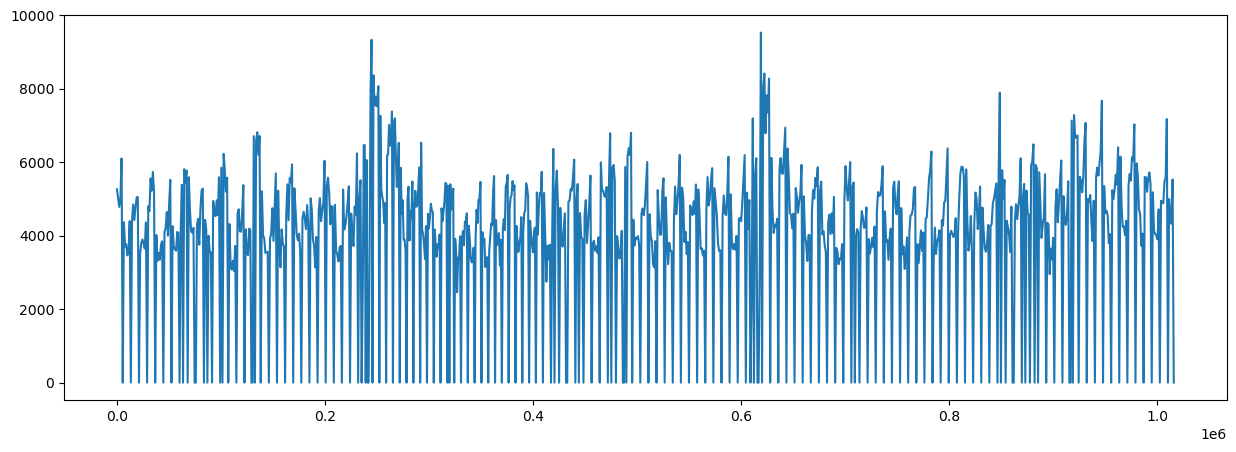

In [10]:
df[df['Store'] == 1]['Sales'].plot(figsize =(15,5));
#store is an ID - unique integer for each store - will be focussing on store with ID 1

In [11]:
# seems to have several seasonal components at different scales 
# seems to have 0 sales date very frequently

In [12]:
''' Understanding data - 
# DayFfWeek from dates can be inferred by python - so will not be using it 
# Sales - this represents our time series 
# Customer - this can also be used as time series or combine it like Sales perc customer 
# Open  whether store was open or not
# Promo - whether or not store was having a promo
# StateHoliday and School Holiday marker'''

' Understanding data - \n# DayFfWeek from dates can be inferred by python - so will not be using it \n# Sales - this represents our time series \n# Customer - this can also be used as time series or combine it like Sales perc customer \n# Open  whether store was open or not\n# Promo - whether or not store was having a promo\n# StateHoliday and School Holiday marker'

In [13]:
(df[df['Store']==1]['Sales']==0).sum()

161

In [14]:
# 161 days when store 1 had 0 sales

In [15]:
store1 =  df[df['Store']==1].copy()

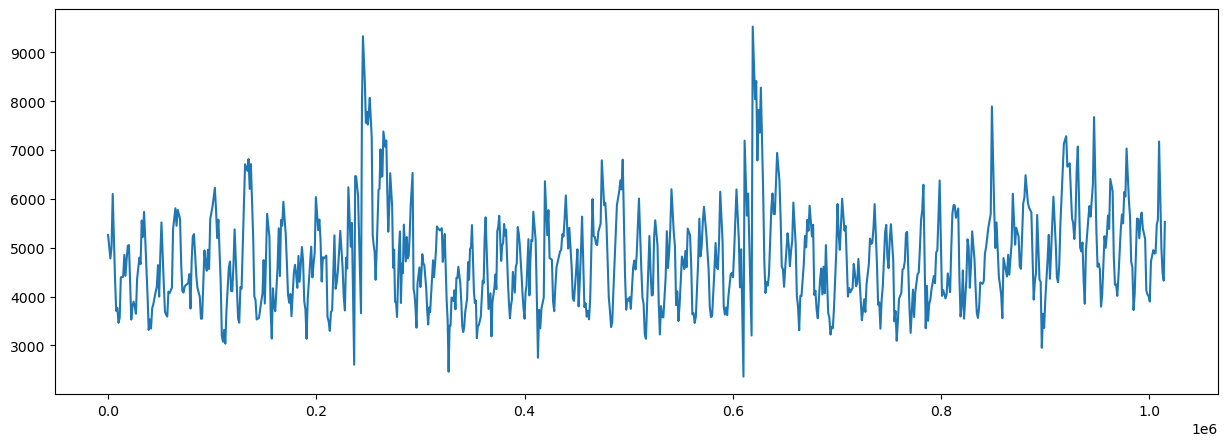

In [16]:
store1[store1['Sales']>0]['Sales'].plot(figsize = (15,5));

In [17]:
# plotting sales for only those days when store is actually open

In [18]:
df[(df['Store']==1) & (df['Sales']==0)].drop_duplicates().head(n=5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
5575,1,7,2015-07-26,0,0,0,0,0,0
13380,1,7,2015-07-19,0,0,0,0,0,0
21185,1,7,2015-07-12,0,0,0,0,0,0
28990,1,7,2015-07-05,0,0,0,0,0,0
36795,1,7,2015-06-28,0,0,0,0,0,0


In [19]:
df[(df['Store']==1) & (df['Sales']==0) & (df['DayOfWeek']!=7)]['StateHoliday'].drop_duplicates()

63555     a
129340    b
241055    c
Name: StateHoliday, dtype: object

In [20]:
# store is closed on DayofWeek =7 which is Sun as well as when there is some state holiday

In [21]:
'''we dont want to model the sales when store is not open.
We already know when store is not open and when there will be no sales - so no need to predict the time series when store is closed.
We know precisely what the value will be for days when store is closed which is 0
'''

'we dont want to model the sales when store is not open.\nWe already know when store is not open and when there will be no sales - so no need to predict the time series when store is closed.\nWe know precisely what the value will be for days when store is closed which is 0\n'

In [22]:
print(df[(df['Store']==1) & (df['Sales']==0)]['Open'].drop_duplicates())
print(df[(df['Store']==1) & (df['Customers']==0)]['Open'].drop_duplicates())

5575    0
Name: Open, dtype: int64
5575    0
Name: Open, dtype: int64


In [23]:
# whenever we have store open, we had some sales - never the case that we didnt have sales when store was open.
# could have happenned that store open, had customers but no sales. Checked the data, this is not the case 

In [24]:
sales0 = store1[store1['Sales'] == 0].index
customers0 = store1[store1['Customers'] == 0].index
store_closed = store1[store1['Open'] == 0].index
print(np.all(sales0 == customers0))
print(np.all(store_closed == customers0))

True
True


In [25]:
store1.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1115,1,4,2015-07-30,5020,546,1,1,0,1
2230,1,3,2015-07-29,4782,523,1,1,0,1
3345,1,2,2015-07-28,5011,560,1,1,0,1
4460,1,1,2015-07-27,6102,612,1,1,0,1


In [26]:
store1.dtypes

Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object

In [27]:
store1['Date'] = pd.to_datetime(store1['Date'])
# all dates are unique since now we only have 1 store - we would want to use it as index

In [28]:
store1.dtypes

Store                     int64
DayOfWeek                 int64
Date             datetime64[ns]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object

In [29]:
store1.set_index('Date', inplace = True)

In [30]:
store1.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-30,1,4,5020,546,1,1,0,1
2015-07-29,1,3,4782,523,1,1,0,1
2015-07-28,1,2,5011,560,1,1,0,1
2015-07-27,1,1,6102,612,1,1,0,1


In [31]:
# prophet needs to have datetime as column and not as index - this means our work increases  - but since we are used to seeing it in
# this format, hence comverted this to index. ALso helps with the plotting since data in descending order but when it plots it auto sorts 
# in ascending order being in the index

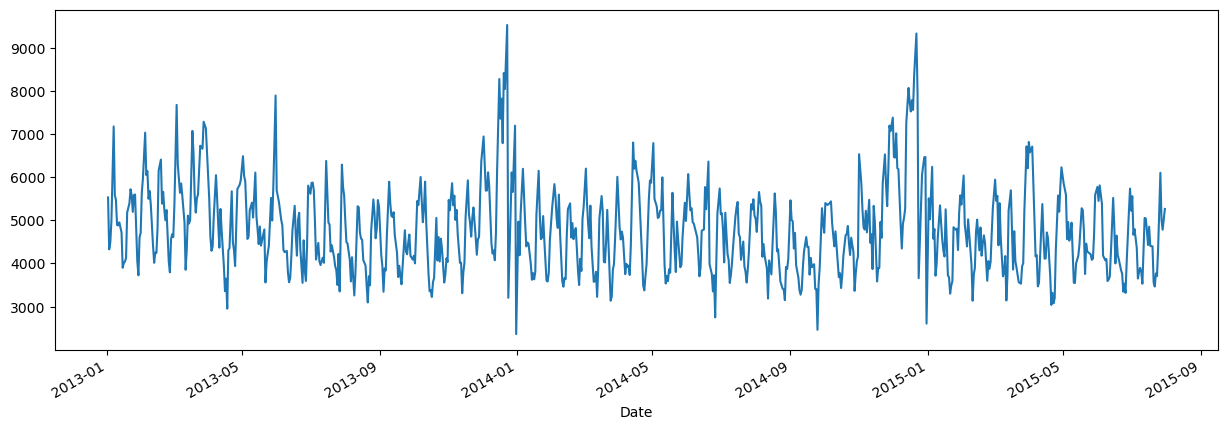

In [32]:
store1[store1['Sales']>0]['Sales'].plot(figsize = (15,5));

In [33]:
# dates in x axis instead of random integers since dates are now index - plus its sorted now automatically. Original data has dates in ascending order

### getting data ready for prophet

In [34]:
### prophet needs data with columns ds and y 

In [35]:
df_p = store1[['Sales']].copy()

In [36]:
df_p['Date']= df_p.index

In [37]:
df_p.head()

,Sales,Date
Date,,
2015-07-31,5263,2015-07-31
2015-07-30,5020,2015-07-30
2015-07-29,4782,2015-07-29
2015-07-28,5011,2015-07-28
2015-07-27,6102,2015-07-27


In [38]:
df_p.tail()

,Sales,Date
Date,,
2013-01-05,4997,2013-01-05
2013-01-04,4486,2013-01-04
2013-01-03,4327,2013-01-03
2013-01-02,5530,2013-01-02
2013-01-01,0,2013-01-01


In [39]:
df_p.sort_index(inplace = True) 
# prophet actually reads the dates, so not necessary to arrange it in chronological (ascending) order, but we are used to this format

In [40]:
df_p.head(20)

,Sales,Date
Date,,
2013-01-01,0,2013-01-01
2013-01-02,5530,2013-01-02
2013-01-03,4327,2013-01-03
2013-01-04,4486,2013-01-04
2013-01-05,4997,2013-01-05
2013-01-06,0,2013-01-06
2013-01-07,7176,2013-01-07
2013-01-08,5580,2013-01-08
2013-01-09,5471,2013-01-09


In [41]:
# new years day 1st day - holiday, then Sun store closed

In [42]:
'''IMPORTANT - PROPHET HAS NO ISSUES WITH MISSING DATA SINCE THE ONLY REGRESSOR IS TIME
ALSO, THERE IS NO NEED FOR TIME SERIES TO BE RECORDED AT REGULARLY SPACED INTERVALS EITHER
'''

'IMPORTANT - PROPHET HAS NO ISSUES WITH MISSING DATA SINCE THE ONLY REGRESSOR IS TIME\nALSO, THERE IS NO NEED FOR TIME SERIES TO BE RECORDED AT REGULARLY SPACED INTERVALS EITHER\n'

In [43]:
df_p.tail()

,Sales,Date
Date,,
2015-07-27,6102,2015-07-27
2015-07-28,5011,2015-07-28
2015-07-29,4782,2015-07-29
2015-07-30,5020,2015-07-30
2015-07-31,5263,2015-07-31


In [44]:
df_p.columns = ['y','ds']

In [45]:
''' the columns have to be named like for prophet'''

' the columns have to be named like for prophet'

In [46]:
df_p.head()

,y,ds
Date,,
2013-01-01,0,2013-01-01
2013-01-02,5530,2013-01-02
2013-01-03,4327,2013-01-03
2013-01-04,4486,2013-01-04
2013-01-05,4997,2013-01-05


### prophet model (including days when store is closed)

In [47]:
''' read notes for more details on the different functions in prophet which we are using below'''

' read notes for more details on the different functions in prophet which we are using below'

In [48]:
m = Prophet()

In [49]:
''' we are not customizing any parameter inside the model - there are a lot of customization we can do inside explained in notes'''

' we are not customizing any parameter inside the model - there are a lot of customization we can do inside explained in notes'

In [50]:
m.fit(df_p)

19:35:59 - cmdstanpy - INFO - Chain [1] start processing
19:36:00 - cmdstanpy - INFO - Chain [1] done processing


In [51]:
''' insanely fast as one of the USPs of Prophet'''

' insanely fast as one of the USPs of Prophet'

In [52]:
future = m.make_future_dataframe(periods=365) 
# naming it future by convention
# this just creates dataframe with dates - both in sample plus out of sample - predictions not yet done 

In [53]:
# future = m.make_future_dataframe(periods=365, freq = 'D') #D is the default frequency

In [54]:
future.head()

,ds
0,2013-01-01
1,2013-01-02
2,2013-01-03
3,2013-01-04
4,2013-01-05


In [55]:
print(future.ds.min())
print(future.ds.max())
print(future.shape)
print(df_p.shape)
print(future.shape[0] - df_p.shape[0])

2013-01-01 00:00:00
2016-07-30 00:00:00
(1307, 1)
(942, 2)
365


In [56]:
''' future dataframe is created with rows for all in sample dates as well as additional 365 days for prediction'''

' future dataframe is created with rows for all in sample dates as well as additional 365 days for prediction'

In [57]:
forecast = m.predict(future) #future dataframe passed as an input

In [58]:
forecast.tail()
# contains predictions for out of sample

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1302,2016-07-26,3724.598999,3052.516060,5920.271404,3702.376252,3747.662285,713.049649,713.049649,713.049649,706.388265,706.388265,706.388265,6.661384,6.661384,6.661384,0.0,0.0,0.0,4437.648648
1303,2016-07-27,3724.361238,2820.228402,5656.492130,3702.043830,3747.488062,502.189794,502.189794,502.189794,510.594230,510.594230,510.594230,-8.404436,-8.404436,-8.404436,0.0,0.0,0.0,4226.551032
1304,2016-07-28,3724.123477,2567.140641,5407.316059,3701.623249,3747.313840,126.204640,126.204640,126.204640,151.302734,151.302734,151.302734,-25.098094,-25.098094,-25.098094,0.0,0.0,0.0,3850.328117
1305,2016-07-29,3723.885716,2938.823488,5724.924770,3701.202667,3747.139617,530.572646,530.572646,530.572646,573.658633,573.658633,573.658633,-43.085987,-43.085987,-43.085987,0.0,0.0,0.0,4254.458361
1306,2016-07-30,3723.647954,3118.120192,6201.048448,3700.782085,3746.965394,937.120652,937.120652,937.120652,999.134741,999.134741,999.134741,-62.014089,-62.014089,-62.014089,0.0,0.0,0.0,4660.768606


In [59]:
forecast.head()
# contains predictions for in sample
# MAKING NON ZERO PREDICTIONS FOR 1st Jan 2013 which we know as holiday - since we didnt customize holidays in model

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-01,4225.020096,3444.209434,6257.829379,4225.020096,4225.020096,614.209019,614.209019,614.209019,706.388265,706.388265,706.388265,-92.179245,-92.179245,-92.179245,0.0,0.0,0.0,4839.229115
1,2013-01-02,4224.265985,3312.545556,6042.793164,4224.265985,4224.265985,356.578031,356.578031,356.578031,510.594230,510.594230,510.594230,-154.016199,-154.016199,-154.016199,0.0,0.0,0.0,4580.844016
2,2013-01-03,4223.511873,2768.283983,5542.922922,4223.511873,4223.511873,-55.330651,-55.330651,-55.330651,151.302734,151.302734,151.302734,-206.633385,-206.633385,-206.633385,0.0,0.0,0.0,4168.181223
3,2013-01-04,4222.757762,3103.575473,5943.894102,4222.757762,4222.757762,323.950210,323.950210,323.950210,573.658633,573.658633,573.658633,-249.708423,-249.708423,-249.708423,0.0,0.0,0.0,4546.707972
4,2013-01-05,4222.003651,3593.243371,6418.942281,4222.003651,4222.003651,716.036237,716.036237,716.036237,999.134741,999.134741,999.134741,-283.098504,-283.098504,-283.098504,0.0,0.0,0.0,4938.039887


In [60]:
''' 
prophet models each component separately - trends, seasonality, holidays etc in addition to the final prediction 'yhat' in the end
- yhat_lower and yhat_upper prediction intervals for yhat
- trend_lower and trend_upper prediction intervals for trend
- columns 'additive_terms' to 'multiplicative_terms_upper' correspond to seasonality - default is additive for seasonality hence seeing only additive
- seasonality splitted into weekly and yearly ( no daily seasonality since data is at daily/date level)
- add 'weekly' + 'yearly' which is equal to total 'additive_terms'
- add 'trend' + 'additive terms' which is equal to total 'yhat'
'''

" \nprophet models each component separately - trends, seasonality, holidays etc in addition to the final prediction 'yhat' in the end\n- yhat_lower and yhat_upper prediction intervals for yhat\n- trend_lower and trend_upper prediction intervals for trend\n- columns 'additive_terms' to 'multiplicative_terms_upper' correspond to seasonality - default is additive for seasonality hence seeing only additive\n- seasonality splitted into weekly and yearly ( no daily seasonality since data is at daily/date level)\n- add 'weekly' + 'yearly' which is equal to total 'additive_terms'\n- add 'trend' + 'additive terms' which is equal to total 'yhat'\n"

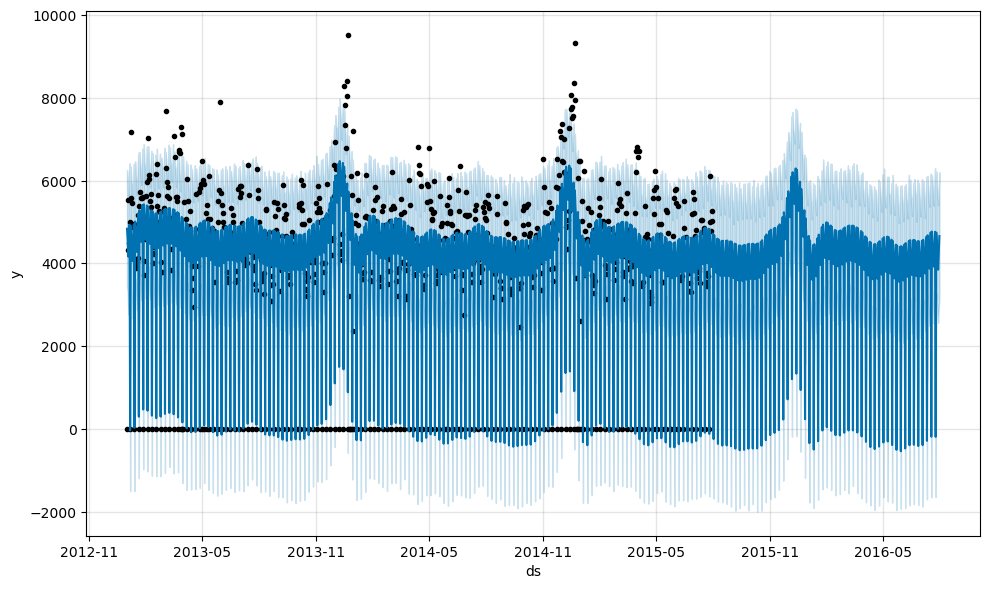

In [61]:
m.plot(forecast);

In [62]:
''' contains in sample predictions as well - USP of prophet - makes it easy plotting all'''

' contains in sample predictions as well - USP of prophet - makes it easy plotting all'

In [63]:
# forecast[forecast['yhat']==0]

In [64]:
''' 
- original time series appears as scatter plot
- model predictions are thick blue line 'yhat'
- corresponding prediction intervals 'yhat lower' and 'yhat upper' - transparent blue lines
- forecast period 'out of sample' data is the one with no black dots
- model not able to precisely determine when sales should be 0 on Sundays or when stores not open
        - predictions yhat for some of these days are negative and prediction intervals fall below zero
        - human intervention required to make sense of these predictions
        - will see how we deal with this later
'''

" \n- original time series appears as scatter plot\n- model predictions are thick blue line 'yhat'\n- corresponding prediction intervals 'yhat lower' and 'yhat upper' - transparent blue lines\n- forecast period 'out of sample' data is the one with no black dots\n- model not able to precisely determine when sales should be 0 on Sundays or when stores not open\n        - predictions yhat for some of these days are negative and prediction intervals fall below zero\n        - human intervention required to make sense of these predictions\n        - will see how we deal with this later\n"

In [65]:
forecast[forecast['yhat']<0].head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
5,2013-01-06,4221.249539,-1499.557538,1347.653890,4221.249539,4221.249539,-4250.719894,-4250.719894,-4250.719894,-3943.881422,-3943.881422,-3943.881422,-306.838472,-306.838472,-306.838472,0.0,0.0,0.0,-29.470355
103,2013-04-14,4147.346632,-1458.118794,1407.681358,4147.346632,4147.346632,-4222.009211,-4222.009211,-4222.009211,-3943.881422,-3943.881422,-3943.881422,-278.127789,-278.127789,-278.127789,0.0,0.0,0.0,-74.662578
110,2013-04-21,4142.067853,-1448.024548,1292.963862,4142.067853,4142.067853,-4208.500301,-4208.500301,-4208.500301,-3943.881422,-3943.881422,-3943.881422,-264.618879,-264.618879,-264.618879,0.0,0.0,0.0,-66.432447
138,2013-05-19,4120.952740,-1538.542152,1353.180070,4120.952740,4120.952740,-4192.299605,-4192.299605,-4192.299605,-3943.881422,-3943.881422,-3943.881422,-248.418183,-248.418183,-248.418183,0.0,0.0,0.0,-71.346865
145,2013-05-26,4115.673962,-1606.581693,1191.011521,4115.673962,4115.673962,-4272.330519,-4272.330519,-4272.330519,-3943.881422,-3943.881422,-3943.881422,-328.449097,-328.449097,-328.449097,0.0,0.0,0.0,-156.656557


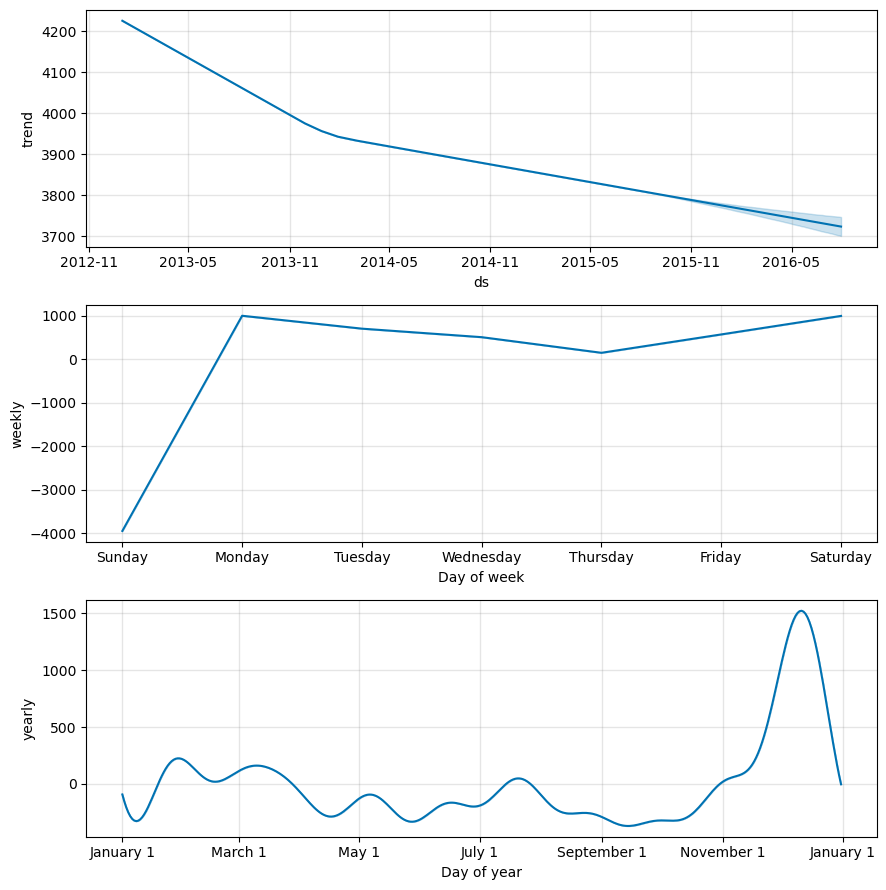

In [66]:
m.plot_components(forecast);

In [67]:
'''
- will show trend, sesonal components and  holiday components if they exist
- one point near 2013-12 when the trend changes - trend is piece wise linear 
- weekly component - impact of sundays very negative since we included Sun when store is closed in our time series
- yearly component - notice spike around christmas holidays which makes sense 
'''

'\n- will show trend, sesonal components and  holiday components if they exist\n- one point near 2013-12 when the trend changes - trend is piece wise linear \n- weekly component - impact of sundays very negative since we included Sun when store is closed in our time series\n- yearly component - notice spike around christmas holidays which makes sense \n'

### model for Open Days only

In [68]:
# we already / will already know when store will be closed

In [69]:
df_p2 = store1[store1['Open'] > 0][['Sales']].copy()
df_p2['Date'] = df_p2.index

In [70]:
df_p2.head()

,Sales,Date
Date,,
2015-07-31,5263,2015-07-31
2015-07-30,5020,2015-07-30
2015-07-29,4782,2015-07-29
2015-07-28,5011,2015-07-28
2015-07-27,6102,2015-07-27


In [71]:
df_p2.columns = ['y','ds']

19:36:03 - cmdstanpy - INFO - Chain [1] start processing
19:36:04 - cmdstanpy - INFO - Chain [1] done processing


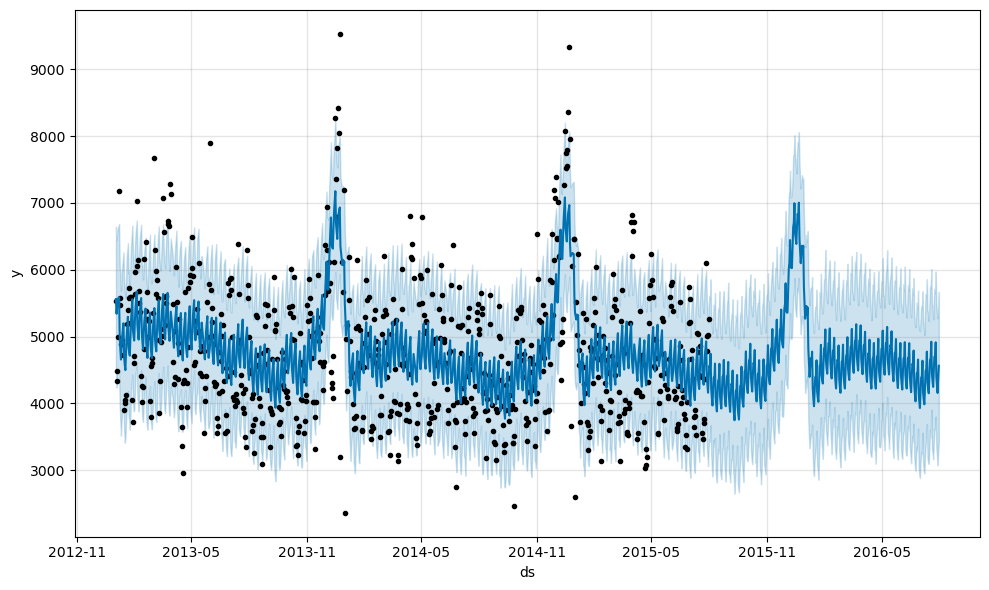

In [72]:
m2 = Prophet()
m2.fit(df_p2)
future2 = m2.make_future_dataframe(periods=365)
forecast2 = m2.predict(future2)
m2.plot(forecast2);

In [73]:
'''
- no longer has to model 0s when store is closed (negative yhat not present)
- prediction intervals are much tighter in this (no longer goes down to negative values
- model predicts Sun and days when stores are not open - be careful - this is not valid but model predicts it
        -prophet is continuous model- so it will have predictions for those days as well (missing data predictions will be there 
            - ignore those predictions when store was closed
'''

'\n- no longer has to model 0s when store is closed (negative yhat not present)\n- prediction intervals are much tighter in this (no longer goes down to negative values\n- model predicts Sun and days when stores are not open - be careful - this is not valid but model predicts it\n        -prophet is continuous model- so it will have predictions for those days as well (missing data predictions will be there \n            - ignore those predictions when store was closed\n'

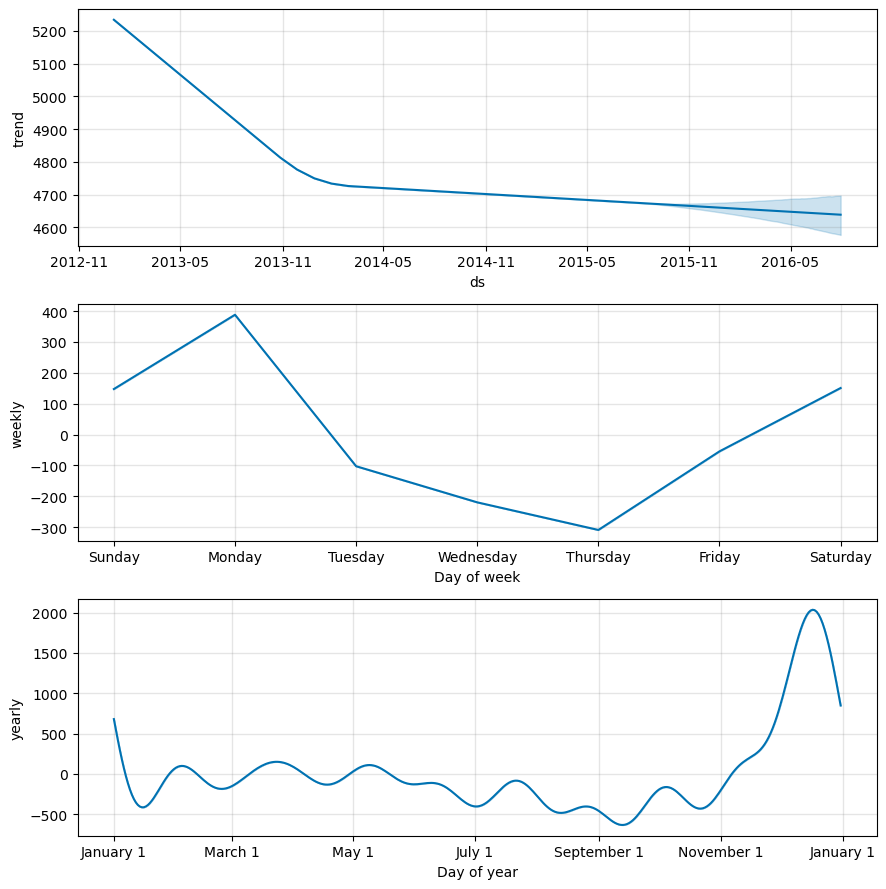

In [74]:
m2.plot_components(forecast2);

In [75]:
'''
- trend is piece wise linear with one changepoint near 2013-12 - steep decrease at start and slower decrease for the rest
- weekly component - very different than before 
        - influence of sun no longer negative but rather high
            - we dont have any data for Sun, model simply interpolating between Saturdat and Monday
            - ignore this 
- yearly component - same pattern as before large increase over winter holiday
'''

'\n- trend is piece wise linear with one changepoint near 2013-12 - steep decrease at start and slower decrease for the rest\n- weekly component - very different than before \n        - influence of sun no longer negative but rather high\n            - we dont have any data for Sun, model simply interpolating between Saturdat and Monday\n            - ignore this \n- yearly component - same pattern as before large increase over winter holiday\n'

### model including Holidays

In [76]:
# incorporating holidays and exogenous regressors

In [77]:
m3 = Prophet()

In [78]:
m3.add_country_holidays(country_name = 'US')
# this is for demonstration purpose only - data is for drug store in europe but no info on which country in europe this data is from

In [79]:
''' the other option would be to pass in the holidays as a dataframe when we build the model object
m = Prophet(holidays = holiday_dataframe)'''

' the other option would be to pass in the holidays as a dataframe when we build the model object\nm = Prophet(holidays = holiday_dataframe)'

In [80]:
m3.fit(df_p2)

19:36:06 - cmdstanpy - INFO - Chain [1] start processing
19:36:07 - cmdstanpy - INFO - Chain [1] done processing


In [81]:
# we are using the dataframe which does incorporate dates when store was closed

In [82]:
future3 = m3.make_future_dataframe(periods = 365)

In [83]:
forecast3 = m3.predict(future3)

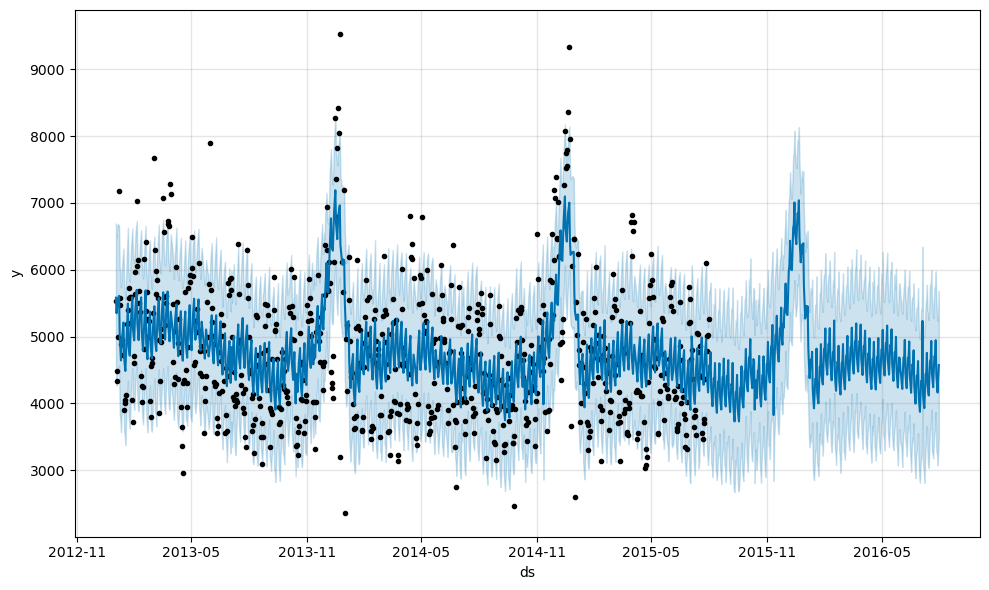

In [84]:
m3.plot(forecast3);

In [85]:
'''pretty similar to our previous model without holidays. Will look at numerical metrics later'''

'pretty similar to our previous model without holidays. Will look at numerical metrics later'

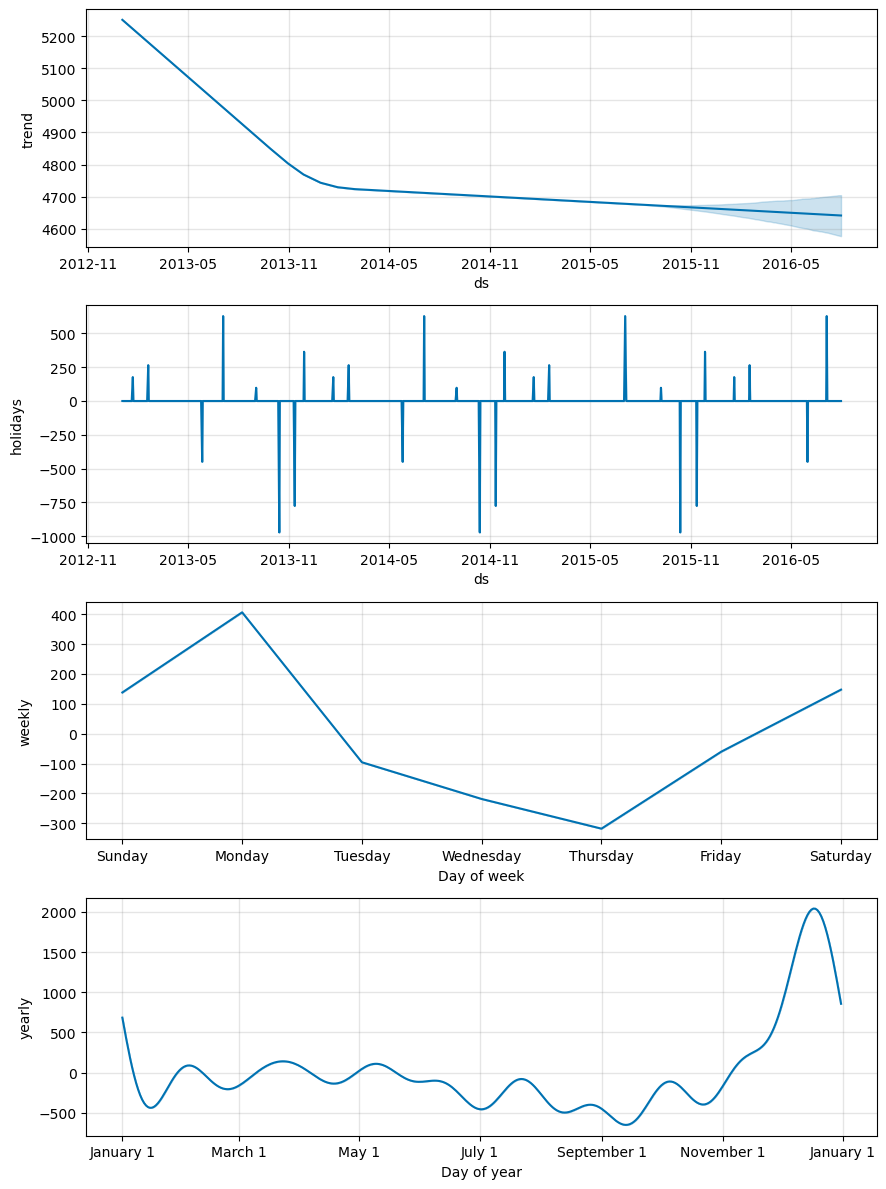

In [86]:
m3.plot_components(forecast3);

In [87]:
''' one extra component which shows the influence of each holiday. Rest looks pretty much the same'''

' one extra component which shows the influence of each holiday. Rest looks pretty much the same'

In [88]:
forecast3

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Columbus Day,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-02,5251.785960,4591.348126,6692.176968,5251.785960,5251.785960,0.0,0.0,0.0,0.0,...,-218.493182,-218.493182,-218.493182,547.963102,547.963102,547.963102,0.0,0.0,0.0,5581.255879
1,2013-01-03,5250.288006,4265.129859,6480.075545,5250.288006,5250.288006,0.0,0.0,0.0,0.0,...,-317.837120,-317.837120,-317.837120,415.935205,415.935205,415.935205,0.0,0.0,0.0,5348.386091
2,2013-01-04,5248.790053,4439.446650,6627.674333,5248.790053,5248.790053,0.0,0.0,0.0,0.0,...,-60.168028,-60.168028,-60.168028,289.505160,289.505160,289.505160,0.0,0.0,0.0,5478.127185
3,2013-01-05,5247.292099,4452.359845,6684.859575,5247.292099,5247.292099,0.0,0.0,0.0,0.0,...,147.592021,147.592021,147.592021,170.180006,170.180006,170.180006,0.0,0.0,0.0,5565.064126
4,2013-01-07,5244.296192,4565.843401,6656.232044,5244.296192,5244.296192,0.0,0.0,0.0,0.0,...,406.406131,406.406131,406.406131,-41.970432,-41.970432,-41.970432,0.0,0.0,0.0,5608.731891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141,2016-07-26,4641.231784,3284.068478,5502.809908,4578.095039,4704.093274,0.0,0.0,0.0,0.0,...,-95.553246,-95.553246,-95.553246,-118.653451,-118.653451,-118.653451,0.0,0.0,0.0,4427.025087
1142,2016-07-27,4641.138434,3242.705016,5349.215420,4577.657424,4704.163603,0.0,0.0,0.0,0.0,...,-218.493182,-218.493182,-218.493182,-138.570878,-138.570878,-138.570878,0.0,0.0,0.0,4284.074373
1143,2016-07-28,4641.045084,3072.031765,5230.812473,4577.219809,4704.233932,0.0,0.0,0.0,0.0,...,-317.837120,-317.837120,-317.837120,-161.809412,-161.809412,-161.809412,0.0,0.0,0.0,4161.398552
1144,2016-07-29,4640.951734,3260.589836,5372.810770,4576.783006,4704.303658,0.0,0.0,0.0,0.0,...,-60.168028,-60.168028,-60.168028,-187.821503,-187.821503,-187.821503,0.0,0.0,0.0,4392.962203


In [89]:
forecast3.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'Christmas Day', 'Christmas Day_lower', 'Christmas Day_upper',
       'Columbus Day', 'Columbus Day_lower', 'Columbus Day_upper',
       'Independence Day', 'Independence Day_lower', 'Independence Day_upper',
       'Independence Day (observed)', 'Independence Day (observed)_lower',
       'Independence Day (observed)_upper', 'Labor Day', 'Labor Day_lower',
       'Labor Day_upper', 'Martin Luther King Jr. Day',
       'Martin Luther King Jr. Day_lower', 'Martin Luther King Jr. Day_upper',
       'Memorial Day', 'Memorial Day_lower', 'Memorial Day_upper',
       'New Year's Day', 'New Year's Day_lower', 'New Year's Day_upper',
       'Thanksgiving Day', 'Thanksgiving Day_lower', 'Thanksgiving Day_upper',
       'Veterans Day', 'Veterans Day_lower', 'Veterans Day_upper',
       'Washington's Birthday', 'Washington's Birthday_lower',
       'Washington's Birthday_upper', 'additive_terms', 'additive_ter

In [90]:
''' we can see that it now has individual columns for each holiday as well as the intervals for individual holidays as well
-- it has future holidays marked as well in out of sample data
-- yhat  = trend  + individual holiday components  + weekly + yearly seasonality
-- additive terms  = individual holiday components + weekly + yearly seasonality'''

' we can see that it now has individual columns for each holiday as well as the intervals for individual holidays as well\n-- it has future holidays marked as well in out of sample data\n-- yhat  = trend  + individual holiday components  + weekly + yearly seasonality\n-- additive terms  = individual holiday components + weekly + yearly seasonality'

In [91]:
''' when we used .add_country_holidays(country_name = 'US') doesnt incorporate New years day or easter etc or black friday
IMPORTANT 
- FOR DATES WHEN STORE WAS CLOSED IN IN SAMPLE PREDICTIONS LIKE NEW YEARS, CHRISTMAS AND SUNDAYS, IN SAMPLE PREDICTIONS ARE NOT PRESENT
- BUT FOR OUT OF SAMPLE DATES, PREDICTIONS ARE PRESENT FOR SUN, CHRISTMAS ETC.
- SINCE, IN CHRISTMAS AND NEW YEARS, SINCE STORE WAS CLOSED , MODEL DIDNT LEARN ANYTHING , AND FOR THESE DATES IN OUT OF SAMPLE PREDICTIONS, THE HOLIDAY 
IMPACT COMPONENT WAS ZERO FOR CHRISTMAS AND NEW YEARS SINCE STORE CLOSED
'''

" when we used .add_country_holidays(country_name = 'US') doesnt incorporate New years day or easter etc or black friday\nIMPORTANT \n- FOR DATES WHEN STORE WAS CLOSED IN IN SAMPLE PREDICTIONS LIKE NEW YEARS, CHRISTMAS AND SUNDAYS, IN SAMPLE PREDICTIONS ARE NOT PRESENT\n- BUT FOR OUT OF SAMPLE DATES, PREDICTIONS ARE PRESENT FOR SUN, CHRISTMAS ETC.\n- SINCE, IN CHRISTMAS AND NEW YEARS, SINCE STORE WAS CLOSED , MODEL DIDNT LEARN ANYTHING , AND FOR THESE DATES IN OUT OF SAMPLE PREDICTIONS, THE HOLIDAY \nIMPACT COMPONENT WAS ZERO FOR CHRISTMAS AND NEW YEARS SINCE STORE CLOSED\n"

In [92]:
# forecast2.to_clipboard(index = False)

In [93]:
# store1.to_clipboard()

### adding exogenous regressors

In [94]:
# in previous example, we called in a function called .add_country_holidays(country_name ='US'), but this was the lazy way
# the below shows custom way of doing things

In [95]:
store1.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-30,1,4,5020,546,1,1,0,1
2015-07-29,1,3,4782,523,1,1,0,1
2015-07-28,1,2,5011,560,1,1,0,1
2015-07-27,1,1,6102,612,1,1,0,1


In [96]:
# actual data set shown above already includes holidays

In [97]:
#checking unique values of the column StateHoliday
set(store1['StateHoliday'])

{'0', 'a', 'b', 'c'}

In [98]:
# 0 mean

In [99]:
set(store1['SchoolHoliday'])

{0, 1}

In [100]:
df_p.shape

(942, 2)

In [101]:
store1.shape

(942, 8)

In [102]:
df_p['open'] = store1['Open'] # binary either 0 or 1
df_p['promo'] = store1['Promo']  # binary either 0 or 1

df_p[['SH1','SH2','SH3']] = pd.get_dummies(store1['StateHoliday'], drop_first = True) 
# statistical models only work on numbers, dummy encode these values  - drop_first = True to use dummy encoding instead of one hot encoding
#one hot would give us 4 values, dummmy encoding will give us 3 values, 4th value is redundant so we dont have to use it


df_p['SchoolHoliday'] = store1['SchoolHoliday'] #binary 0 or 1

In [103]:
df_p.head()

,y,ds,open,promo,SH1,SH2,SH3,SchoolHoliday
Date,,,,,,,,
2013-01-01,0,2013-01-01,0,0,True,False,False,1
2013-01-02,5530,2013-01-02,1,0,False,False,False,1
2013-01-03,4327,2013-01-03,1,0,False,False,False,1
2013-01-04,4486,2013-01-04,1,0,False,False,False,1
2013-01-05,4997,2013-01-05,1,0,False,False,False,1


In [104]:
store1.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-30,1,4,5020,546,1,1,0,1
2015-07-29,1,3,4782,523,1,1,0,1
2015-07-28,1,2,5011,560,1,1,0,1
2015-07-27,1,1,6102,612,1,1,0,1


In [105]:
''' both the dataframes above have different ordering of their index - but when we do something like df_p['open'] = store1['Open'] , it does kind of 
join based on index of the 2 dataframes'''

" both the dataframes above have different ordering of their index - but when we do something like df_p['open'] = store1['Open'] , it does kind of \njoin based on index of the 2 dataframes"

In [106]:
''' note that the dataframe we are passing in has all the data which has dates on which store was closed'''
''' passing store open/close as a separate regressor'''

m4 = Prophet()
m4.add_regressor('open', mode = 'multiplicative')  # default mode is seasonality model 
# using multiplicative since we think that when store is closed, model will multiply with 0

m4.add_regressor('promo', mode = 'additive')
m4.add_regressor('SH1', mode = 'additive')
m4.add_regressor('SH2', mode = 'additive')
m4.add_regressor('SH3', mode = 'additive')
m4.add_regressor('SchoolHoliday', mode = 'additive')
m4.fit(df_p) 

19:36:10 - cmdstanpy - INFO - Chain [1] start processing
19:36:10 - cmdstanpy - INFO - Chain [1] done processing


In [107]:
future4 = m4.make_future_dataframe(periods = 365)

In [108]:
train_idx = future4['ds'].isin(df_p.index)  
# checking if ds value is in the index for the input dataframe which has train data
# future4 has both insample + 365 days of out of sample dates

test_idx = ~train_idx

In [109]:
future4.head()

,ds
0,2013-01-01
1,2013-01-02
2,2013-01-03
3,2013-01-04
4,2013-01-05


In [110]:
''' despite adding the regressors in the m4 model, we dont see the regressors in the future4 dataframe.
Regressors need to be added in the futures dataframe which is required in order to make predictions.
We are specifying the input values to be used for each prediction.

for train set, its easy since it is just the copy of what we had before.

this will be a bit difficult for test set since we dont know when this holiday will be there for the european country.

this is not automatically created since i think test data for regressors is not provided as an input during model training since we only provide 
training data.
'''


' despite adding the regressors in the m4 model, we dont see the regressors in the future4 dataframe.\nRegressors need to be added in the futures dataframe which is required in order to make predictions.\nWe are specifying the input values to be used for each prediction.\n\nfor train set, its easy since it is just the copy of what we had before.\n\nthis will be a bit difficult for test set since we dont know when this holiday will be there for the european country.\n\nthis is not automatically created since i think test data for regressors is not provided as an input during model training since we only provide \ntraining data.\n'

In [111]:
regressors = ['open','promo','SH1','SH2','SH3','SchoolHoliday']
for r in regressors:
    future4.loc[train_idx, r] = df_p[r].to_list()

C:\Users\palit\AppData\Local\Temp\ipykernel_228\2231029197.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, F

In [112]:
future4.head()

,ds,open,promo,SH1,SH2,SH3,SchoolHoliday
0,2013-01-01,0.0,0.0,True,False,False,1.0
1,2013-01-02,1.0,0.0,False,False,False,1.0
2,2013-01-03,1.0,0.0,False,False,False,1.0
3,2013-01-04,1.0,0.0,False,False,False,1.0
4,2013-01-05,1.0,0.0,False,False,False,1.0


In [113]:
future4.tail()

,ds,open,promo,SH1,SH2,SH3,SchoolHoliday
1302,2016-07-26,NaN,NaN,NaN,NaN,NaN,NaN
1303,2016-07-27,NaN,NaN,NaN,NaN,NaN,NaN
1304,2016-07-28,NaN,NaN,NaN,NaN,NaN,NaN
1305,2016-07-29,NaN,NaN,NaN,NaN,NaN,NaN
1306,2016-07-30,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
# the above are blank since they are for test set - adding the below for test set
# pretending we know this for test set (we actually do not since we are not sure which european country this store is located)

future4.loc[test_idx, 'open'] = future4.loc[test_idx, 'ds'].apply(lambda x : 1.0 * (x.weekday() != 6))

# for other regressors, we are simply copy from past 365 days of actual training data # assumption
for r in regressors[1:]:
    future4.loc[test_idx, r] = df_p.iloc[-365:][r].to_list() 

In [115]:
df_p.tail()

,y,ds,open,promo,SH1,SH2,SH3,SchoolHoliday
Date,,,,,,,,
2015-07-27,6102,2015-07-27,1,1,False,False,False,1
2015-07-28,5011,2015-07-28,1,1,False,False,False,1
2015-07-29,4782,2015-07-29,1,1,False,False,False,1
2015-07-30,5020,2015-07-30,1,1,False,False,False,1
2015-07-31,5263,2015-07-31,1,1,False,False,False,1


In [116]:
future4.tail()

,ds,open,promo,SH1,SH2,SH3,SchoolHoliday
1302,2016-07-26,1.0,1.0,False,False,False,1.0
1303,2016-07-27,1.0,1.0,False,False,False,1.0
1304,2016-07-28,1.0,1.0,False,False,False,1.0
1305,2016-07-29,1.0,1.0,False,False,False,1.0
1306,2016-07-30,1.0,1.0,False,False,False,1.0


In [117]:
forecast4 = m4.predict(future4) # if we hadnt added the regressors earlier, it would have thrown error saying regressors missing

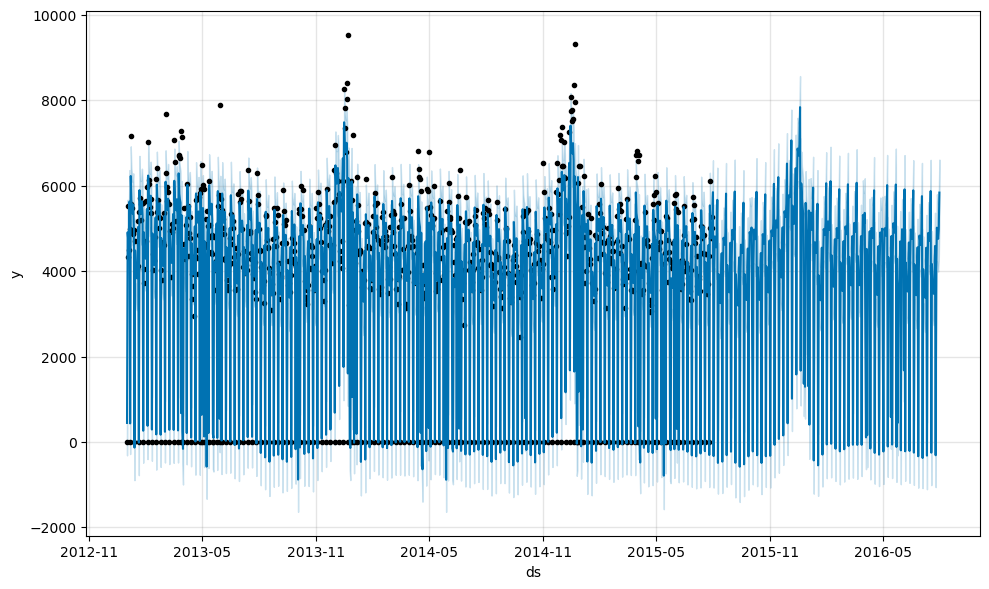

In [118]:
m4.plot(forecast4);

In [119]:
''' 
- not what we expected, model giving us negative values - still doesnt know sales 0 when store is not open
    - we should probably just remove those days from the time series''' 

' \n- not what we expected, model giving us negative values - still doesnt know sales 0 when store is not open\n    - we should probably just remove those days from the time series'

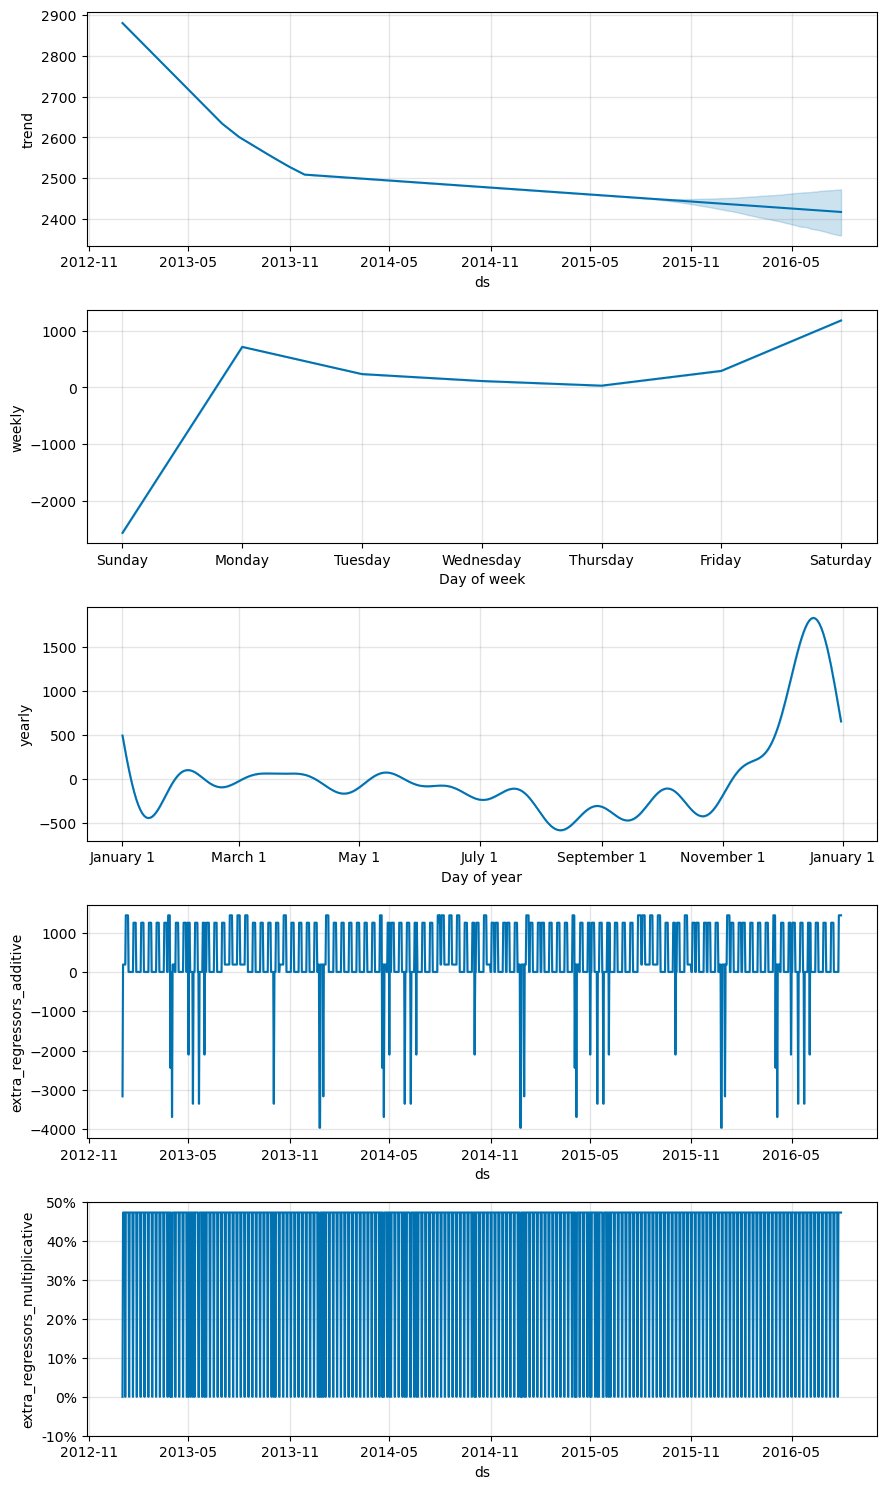

In [120]:
m4.plot_components(forecast4);

In [121]:
''' 
- adding Sun in the data has a negative influence despite adding the 'open' field denoting store open or close
        - better to just remove days when store is closed
- yearly seasonality- we still see the exact graph which came without regressors - still see a peak around winter school holiday
        - meaning adding these new regressors didnt completely account for these events
- components of regressors also plotted based on the mode we specified - additive and multiplicative components
'''

" \n- adding Sun in the data has a negative influence despite adding the 'open' field denoting store open or close\n        - better to just remove days when store is closed\n- yearly seasonality- we still see the exact graph which came without regressors - still see a peak around winter school holiday\n        - meaning adding these new regressors didnt completely account for these events\n- components of regressors also plotted based on the mode we specified - additive and multiplicative components\n"

### Cross-validation

In [122]:
from prophet.diagnostics import cross_validation

In [123]:
df_cv = cross_validation(
    m,                        # will take in the trained model - SHOULD HAVE USED M2 WHICH EXCLUDES THE DATES WHEN STORES WERE CLOSED
    initial = '730 days',     # this is the initial size of the 1st train set 
    period = '30 days',       # stepping forward the train set size by this much time period -step size
    horizon = '60 days')      # at each iteration of train set, the time period ahead to forecast

  0%|          | 0/6 [00:00<?, ?it/s]

19:36:13 - cmdstanpy - INFO - Chain [1] start processing
19:36:14 - cmdstanpy - INFO - Chain [1] done processing
19:36:14 - cmdstanpy - INFO - Chain [1] start processing
19:36:14 - cmdstanpy - INFO - Chain [1] done processing
19:36:14 - cmdstanpy - INFO - Chain [1] start processing
19:36:14 - cmdstanpy - INFO - Chain [1] done processing
19:36:15 - cmdstanpy - INFO - Chain [1] start processing
19:36:15 - cmdstanpy - INFO - Chain [1] done processing
19:36:15 - cmdstanpy - INFO - Chain [1] start processing
19:36:15 - cmdstanpy - INFO - Chain [1] done processing
19:36:16 - cmdstanpy - INFO - Chain [1] start processing
19:36:16 - cmdstanpy - INFO - Chain [1] done processing


In [124]:
''' m2 model's cross validation - one with data removed for dates when store was closed - is done later on'''

" m2 model's cross validation - one with data removed for dates when store was closed - is done later on"

In [125]:
df_cv

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2015-01-03,4612.183309,3152.030362,6110.746798,5023,2015-01-02
1,2015-01-04,-441.878139,-1881.803109,936.281140,0,2015-01-02
2,2015-01-05,4574.131377,3065.872415,6044.471118,6239,2015-01-02
3,2015-01-06,4189.020494,2739.675534,5599.611202,4574,2015-01-02
4,2015-01-07,3950.876574,2463.069470,5428.341596,4796,2015-01-02
...,...,...,...,...,...,...
355,2015-07-27,4791.395410,3456.807206,6315.533051,6102,2015-06-01
356,2015-07-28,4466.849519,2986.944538,5851.361327,5011,2015-06-01
357,2015-07-29,4252.228830,2748.148245,5586.425944,4782,2015-06-01
358,2015-07-30,3876.622614,2360.738082,5266.906044,5020,2015-06-01


In [126]:
''' 
cut off tells us where we started our forecasts from
ds is the timestamp for each forecasted value - meaning forecast is for date 'ds'
'''


" \ncut off tells us where we started our forecasts from\nds is the timestamp for each forecasted value - meaning forecast is for date 'ds'\n"

In [127]:
''' since 1st date in the training set was 01 jan 2013, 
 - then 1st training set would be 01 jan 2013 + 730 = 01 jan 2015. so the 1st set of predictions would have cut off date from 02/01/2015.
     - predictions for cut off date 02/01/2015 would be from 03/01/2015 to 03/01/2015 + 60 days  = 03/03/15
 - 2nd training set would be from 01/jan/2013 + 730 + 30 = 31 Jan 2015 , so 2nd set of preditioins would have cut off date from 01/02/15
     - predictons for cut off date 01/01/2015 would be from 02/02/2015 to 02/02/2015 +  60 days = 02/04/15
 - .....
 - 1st and 2nd set of predictions for different cut off dates have overlapping dates. eg 15/02/2015 would have 2 predictions one for each cut off date'''
     

' since 1st date in the training set was 01 jan 2013, \n - then 1st training set would be 01 jan 2013 + 730 = 01 jan 2015. so the 1st set of predictions would have cut off date from 02/01/2015.\n     - predictions for cut off date 02/01/2015 would be from 03/01/2015 to 03/01/2015 + 60 days  = 03/03/15\n - 2nd training set would be from 01/jan/2013 + 730 + 30 = 31 Jan 2015 , so 2nd set of preditioins would have cut off date from 01/02/15\n     - predictons for cut off date 01/01/2015 would be from 02/02/2015 to 02/02/2015 +  60 days = 02/04/15\n - .....\n - 1st and 2nd set of predictions for different cut off dates have overlapping dates. eg 15/02/2015 would have 2 predictions one for each cut off date'

In [128]:
from prophet.diagnostics import performance_metrics

In [129]:
pm = performance_metrics(df_cv)
pm

,horizon,mse,rmse,mae,mdape,smape,coverage
0,6 days,2.223636e+06,1491.186110,919.609816,0.138169,0.550357,0.805556
1,7 days,1.587809e+06,1260.082987,758.556450,0.134227,0.491755,0.833333
2,8 days,1.462808e+06,1209.465833,705.495506,0.124071,0.486258,0.888889
3,9 days,1.165782e+06,1079.713909,689.723887,0.145229,0.453825,0.916667
4,10 days,5.043820e+05,710.198599,578.954183,0.156795,0.460461,0.944444
5,11 days,4.956430e+05,704.019148,570.084299,0.148970,0.403627,0.944444
6,12 days,8.562216e+05,925.322413,634.406011,0.148970,0.450544,0.944444
7,13 days,8.255995e+05,908.625081,605.628842,0.135744,0.441898,0.944444
8,14 days,7.805913e+05,883.510801,566.032339,0.123950,0.433057,0.944444
9,15 days,6.533861e+05,808.323022,496.764729,0.103078,0.414432,0.972222


In [130]:
''' mape is not present above since mape formula is average(abs(delta)/y_actual). Since y_actual is 0 in some cases, mape has been skipped'''

' mape is not present above since mape formula is average(abs(delta)/y_actual). Since y_actual is 0 in some cases, mape has been skipped'

In [131]:
''' 
since the last training data is 31st july 2015, and  horizon if 60 days , the last cutoff could not be greater than 01st June 2015
default horizon is 10% of horizon - 10% of 60 days  = 6 days
so, it looks at multiple iterations of different training set / test set combinations 
and then looks at forecasts 6 days ahead of the cut off date for each this combinations
    - average error of all predictions made exactly 6 days after the 'cutoff'
and calculates the average of mapes , mse etc for 6 days ahead of the cut off for each combination.

Similarly, it does it for 7 days ,,,,,going all the way to looking 60 days + cutoff for each of the combination to calculate the metrics '''


" \nsince the last training data is 31st july 2015, and  horizon if 60 days , the last cutoff could not be greater than 01st June 2015\ndefault horizon is 10% of horizon - 10% of 60 days  = 6 days\nso, it looks at multiple iterations of different training set / test set combinations \nand then looks at forecasts 6 days ahead of the cut off date for each this combinations\n    - average error of all predictions made exactly 6 days after the 'cutoff'\nand calculates the average of mapes , mse etc for 6 days ahead of the cut off for each combination.\n\nSimilarly, it does it for 7 days ,,,,,going all the way to looking 60 days + cutoff for each of the combination to calculate the metrics "

In [132]:
''' as we predict further away from the future (meaning the horixon increaes in the above dataframe), the model should be less and less confident
cutoff'''

' as we predict further away from the future (meaning the horixon increaes in the above dataframe), the model should be less and less confident\ncutoff'

In [133]:
from prophet.plot import plot_cross_validation_metric

C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


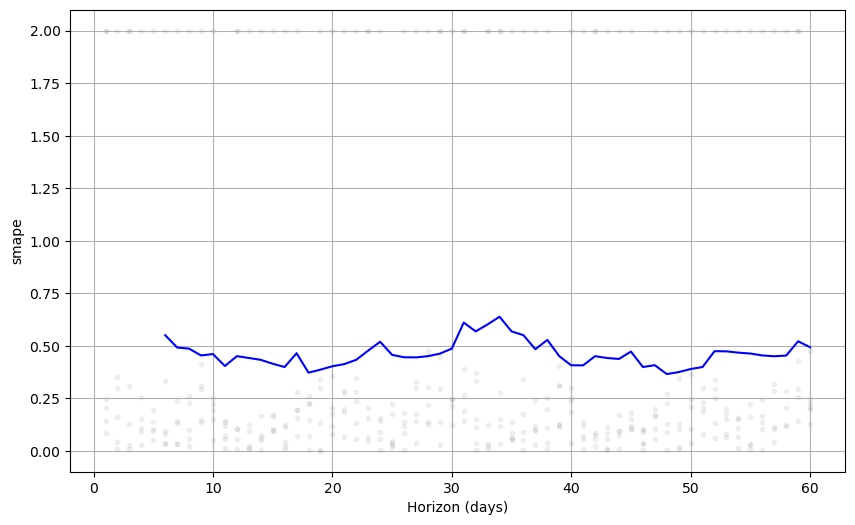

In [134]:
plot_cross_validation_metric(df_cv, metric ='smape');

In [135]:
''' 
blue line rolling window estimate of all the cutoffs for a horizon
raw metrics as a scatter plot of individual cut off
error stays relatively constant
'''

' \nblue line rolling window estimate of all the cutoffs for a horizon\nraw metrics as a scatter plot of individual cut off\nerror stays relatively constant\n'

In [136]:
df_cv2 = cross_validation(
    m2,
    initial = '730 days',
    period = '30 days',
    horizon = '60 days')

  0%|          | 0/6 [00:00<?, ?it/s]

19:37:24 - cmdstanpy - INFO - Chain [1] start processing
19:37:24 - cmdstanpy - INFO - Chain [1] done processing
19:37:25 - cmdstanpy - INFO - Chain [1] start processing
19:37:25 - cmdstanpy - INFO - Chain [1] done processing
19:37:25 - cmdstanpy - INFO - Chain [1] start processing
19:37:25 - cmdstanpy - INFO - Chain [1] done processing
19:37:25 - cmdstanpy - INFO - Chain [1] start processing
19:37:26 - cmdstanpy - INFO - Chain [1] done processing
19:37:26 - cmdstanpy - INFO - Chain [1] start processing
19:37:26 - cmdstanpy - INFO - Chain [1] done processing
19:37:26 - cmdstanpy - INFO - Chain [1] start processing
19:37:26 - cmdstanpy - INFO - Chain [1] done processing


In [137]:
pm2 = performance_metrics(df_cv2)

In [143]:
pm2.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,7 days,529216.347810,727.472575,565.929613,0.124764,0.098103,0.119359,0.862069
1,8 days,503482.186781,709.564787,579.996711,0.139841,0.108191,0.127566,0.862069
2,9 days,812290.818127,901.271778,740.285953,0.194879,0.148424,0.169598,0.758621
3,10 days,948790.173116,974.058609,832.200844,0.223361,0.200755,0.192755,0.689655
4,11 days,952684.325814,976.055493,850.329483,0.227789,0.200755,0.197441,0.703448


In [144]:
''' since we had removed the dates when store was closed, now mape becomes defined for all datapoints since y_act is never 0'''

' since we had removed the dates when store was closed, now mape becomes defined for all datapoints since y_act is never 0'

C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


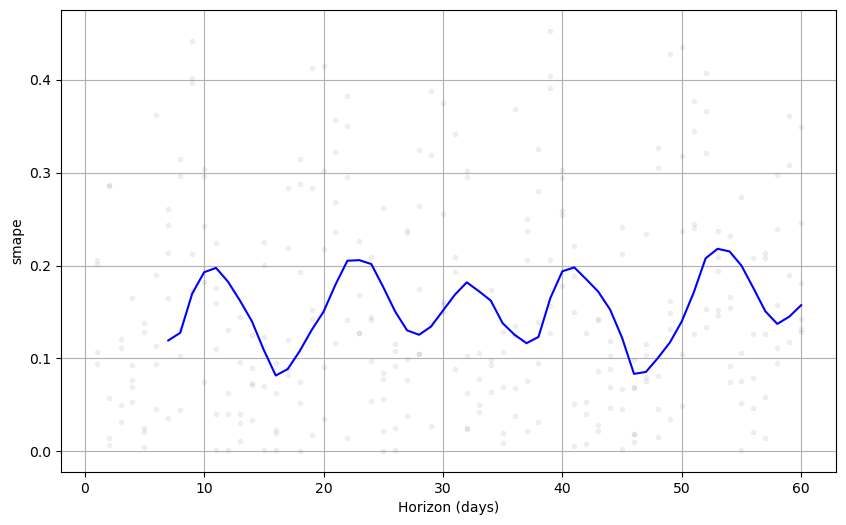

In [139]:
plot_cross_validation_metric(df_cv2, metric = 'smape');

In [140]:
''' cyclical pattern but overall smape moving average showing less smape compared to the previous model
although individual raw data scatter plot smape does look increased '''


' cyclical pattern but overall smape moving average showing less smape compared to the previous model\nalthough individual raw data scatter plot smape does look increased '

In [146]:
df_cv3 = cross_validation(
    m3, # this is where we added US holidays 
    initial = '730 days',
    period = '30 days',
    horizon = '60 days')

  0%|          | 0/6 [00:00<?, ?it/s]

19:44:24 - cmdstanpy - INFO - Chain [1] start processing
19:44:24 - cmdstanpy - INFO - Chain [1] done processing
19:44:24 - cmdstanpy - INFO - Chain [1] start processing
19:44:24 - cmdstanpy - INFO - Chain [1] done processing
19:44:25 - cmdstanpy - INFO - Chain [1] start processing
19:44:25 - cmdstanpy - INFO - Chain [1] done processing
19:44:25 - cmdstanpy - INFO - Chain [1] start processing
19:44:25 - cmdstanpy - INFO - Chain [1] done processing
19:44:26 - cmdstanpy - INFO - Chain [1] start processing
19:44:26 - cmdstanpy - INFO - Chain [1] done processing
19:44:26 - cmdstanpy - INFO - Chain [1] start processing
19:44:26 - cmdstanpy - INFO - Chain [1] done processing


In [147]:
pm3 = performance_metrics(df_cv3)
pm3.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,7 days,528266.807794,726.819653,563.802626,0.124251,0.098476,0.118839,0.862069
1,8 days,504209.060183,710.076799,578.112304,0.139371,0.112942,0.127113,0.862069
2,9 days,814044.403389,902.244093,738.635119,0.194492,0.150499,0.169189,0.758621
3,10 days,951362.314033,975.378036,832.049957,0.223229,0.197754,0.192647,0.689655
4,11 days,954549.058384,977.010265,849.699175,0.227534,0.199710,0.197283,0.703448


C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


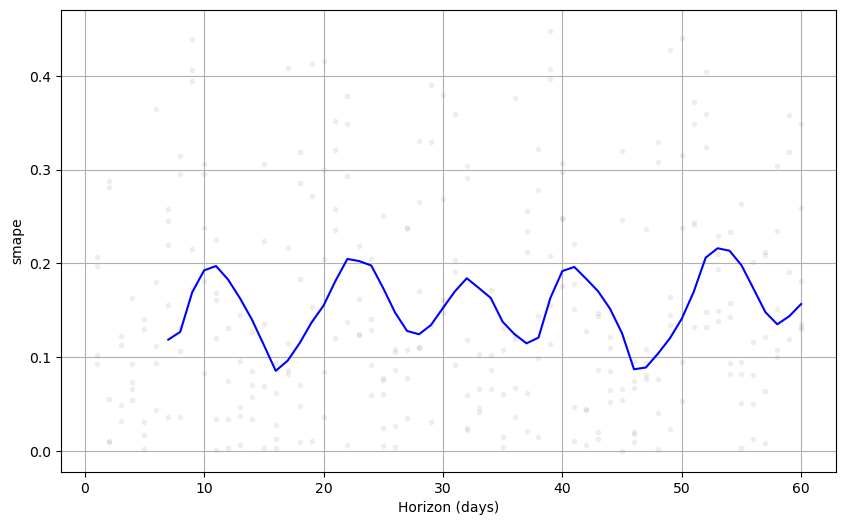

In [150]:
plot_cross_validation_metric(df_cv3, metric = 'smape');

In [151]:
df_cv4 = cross_validation(
    m4, # this is where we added external regressors
    initial = '730 days',
    period = '30 days',
    horizon = '60 days')

pm4 = performance_metrics(df_cv4)

  0%|          | 0/6 [00:00<?, ?it/s]

19:46:20 - cmdstanpy - INFO - Chain [1] start processing
19:46:20 - cmdstanpy - INFO - Chain [1] done processing
19:46:21 - cmdstanpy - INFO - Chain [1] start processing
19:46:21 - cmdstanpy - INFO - Chain [1] done processing
19:46:21 - cmdstanpy - INFO - Chain [1] start processing
19:46:21 - cmdstanpy - INFO - Chain [1] done processing
19:46:22 - cmdstanpy - INFO - Chain [1] start processing
19:46:22 - cmdstanpy - INFO - Chain [1] done processing
19:46:22 - cmdstanpy - INFO - Chain [1] start processing
19:46:22 - cmdstanpy - INFO - Chain [1] done processing
19:46:23 - cmdstanpy - INFO - Chain [1] start processing
19:46:23 - cmdstanpy - INFO - Chain [1] done processing


C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\palit\AppData\Roaming\Python\Python312\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


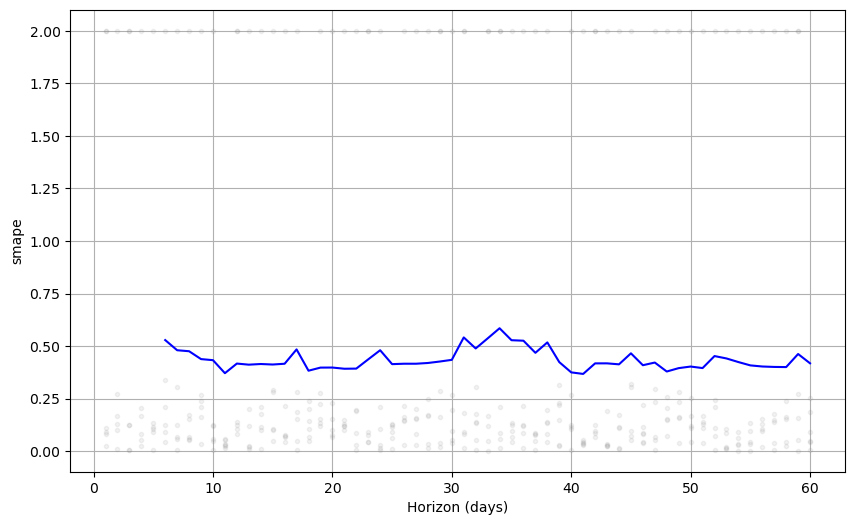

In [152]:
plot_cross_validation_metric(df_cv4, metric = 'smape');

In [154]:
''' similar pattern as the 1st model - 1st model and the 4th model both had negative yhats - both 1st and 4th included 0 sale days  '''

' similar pattern as the 1st model - 1st model and the 4th model both had negative yhats - both 1st and 4th included 0 sale days  '

In [155]:
pm['smape'].mean(),pm2['smape'].mean(),pm3['smape'].mean(),pm4['smape'].mean() 

(0.461775405515676,
 0.15371307521687194,
 0.15402386271741614,
 0.4357805114466114)

In [158]:
'''1st model worst smape, 4th model where we added external regressors but kept the store close dates as well'''
''' best mape was model where we just removed the store close dates . 3rd model where we added US holiday and kept the store close dates removed 
didnt help'''

' best mape was model where we just removed the store close dates . 3rd model where we added US holiday and kept the store close dates removed \ndidnt help'

In [156]:
'''the best model came when we just removed the dates when store was closed, we could have tried 4th model where we added regressors
but we kept the dates when store was closed - maybe try other model with external regressors and removing dates when store was closed'''

'the best model came when we just removed the dates when store was closed, we could have tried 4th model where we added regressors\nbut we kept the dates when store was closed - maybe try other model with external regressors and removing dates when store was closed'

### Changepoint detection

In [160]:
from prophet.plot import add_changepoints_to_plot

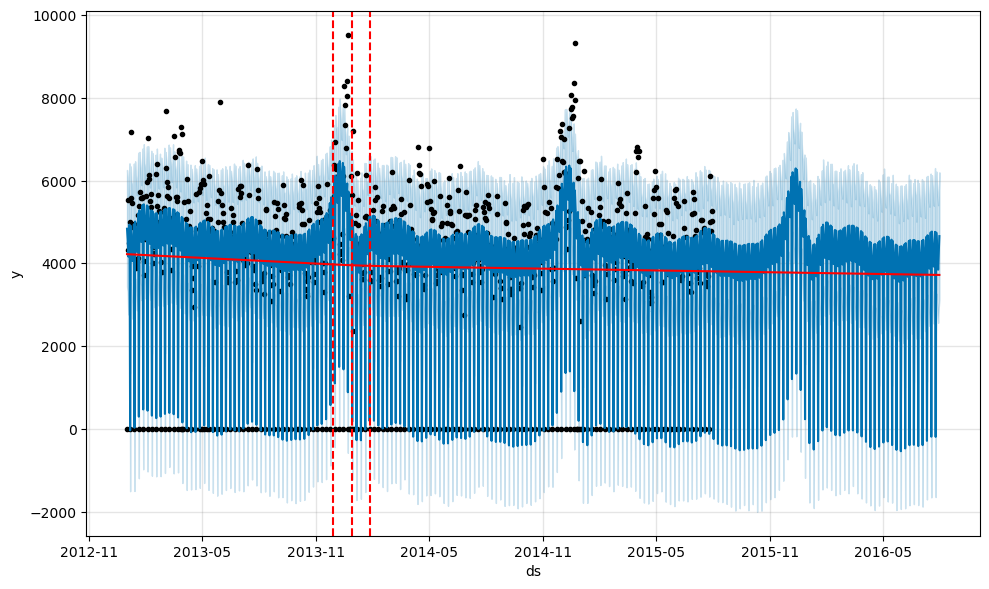

In [161]:
fig =  m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)

In [162]:
''' 2 changepoints - trend goes from more steep to less steep'''

' 2 changepoints - trend goes from more steep to less steep'

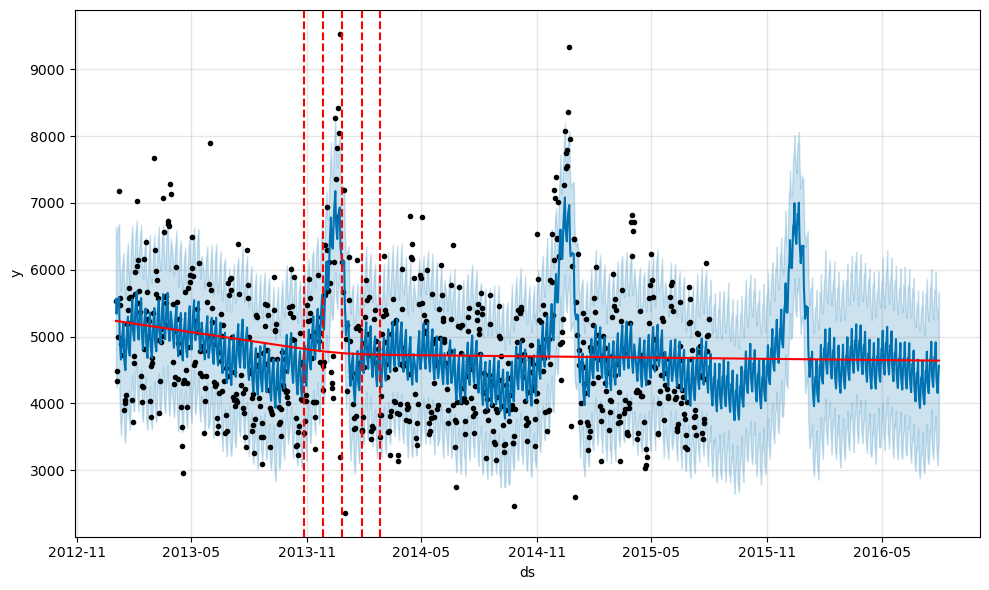

In [163]:
fig = m2.plot(forecast2)
a =  add_changepoints_to_plot(fig.gca(), m2, forecast2)

In [166]:
''' why are changepoints equally spaced?
-n_changepoints = 25 , model chooses the changepoints from amonf those changepoints '''

' why are changepoints equally spaced?\n-n_changepoints = 25 , model chooses the changepoints from amonf those changepoints '

In [167]:
'''many more changepoints here - these are governed by the parameters we pass inside the model object'''

# - changepoints parameter
# - n_changepoints - !!! BY DEFAULT THIS IS 25, MODEL IS CHOOSING THE CHANGEPOINTS FROM AMONG THOSE 25
# - changepoint_range
# - changepoint_prior_scale


'''
 m = Prophet(
                growth  = 'linear',                      # or 'logistic'
                changepoints = None,                     # or list of time stamps 
                n_changepoints = 25,                     # if no explicit timestamps provided above 
                changepoint_range = 0.8,                 # percentage of dataset where we want the potential changepoint to exist # if set to 80%, means no changepoint will
                                                         # exist in the final 20% of your dataset.
                                                         # reason for this parameter is it might overfit due to lack of data near the end
                yearly_seasonality = 'auto',             # or True/False
                weekly_seasonality ='auto',              # or True/False     
                daily_seasonality ='auto',               # or True/False     
                holidays= None,                          # or dataframe # pass in ur holidays, in a specially formatted dataframe with those dates # allows to specify surrounding days and other options
                seasonality_mode = 'additive',           # or 'multiplicative'
                seasonality_prior_scale = 10.0,          # since prophet is a bayesian model, tune the below based on the fitted values - try these values untill u get reasonable results 
                holidays_prior_scale = 10.0, 
                changepoint_prior_scale = 0.05,          # increase or decrease the sensitivity of the changepoints
                MCMC = ,                                 # not discussed here
                uncertainity intervals =,                # not discussed here 
                )
'''
           

"\n m = Prophet(\n                growth  = 'linear',                      # or 'logistic'\n                changepoints = None,                     # or list of time stamps \n                n_changepoints = 25,                     # if no explicit timestamps provided above \n                changepoint_range = 0.8,                 # percentage of dataset where we want the potential changepoint to exist # if set to 80%, means no changepoint will\n                                                         # exist in the final 20% of your dataset.\n                                                         # reason for this parameter is it might overfit due to lack of data near the end\n                yearly_seasonality = 'auto',             # or True/False\n                weekly_seasonality ='auto',              # or True/False     \n                daily_seasonality ='auto',               # or True/False     \n                holidays= None,                          # or dataframe # pas

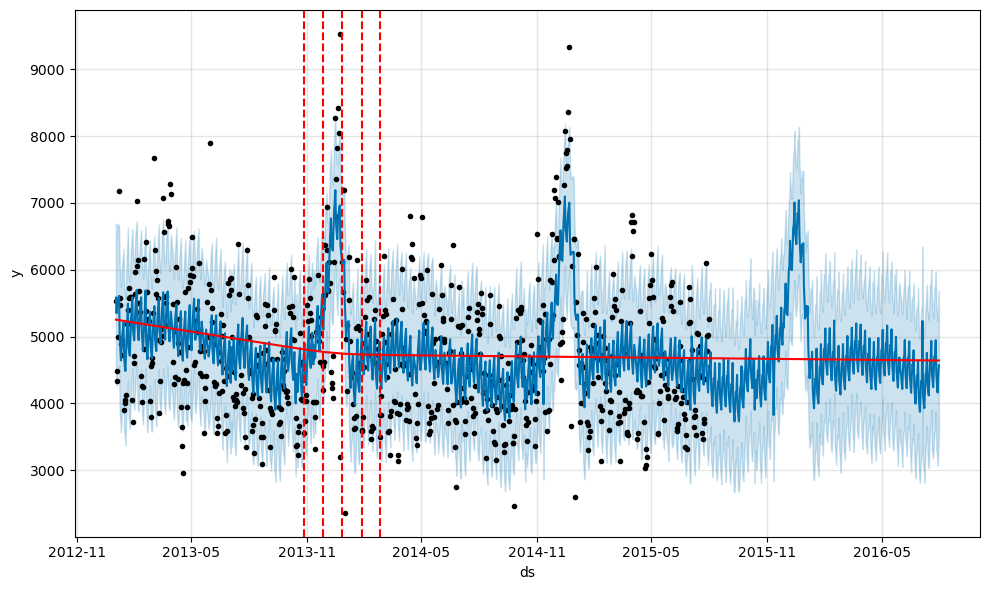

In [169]:
fig = m3.plot(forecast3)
a =  add_changepoints_to_plot(fig.gca(), m3, forecast3)

In [170]:
''' pretty much the same result'''

' pretty much the same result'

In [171]:
''' TUNING THE PRIOR FOR CHANGEPOINT DETECTION'''

' TUNING THE PRIOR FOR CHANGEPOINT DETECTION'

In [174]:
# by changing the prior changepoint_prior_scale, by default it is 0.05.
# increasing this will increase the flexibility making it overfit 

20:09:24 - cmdstanpy - INFO - Chain [1] start processing
20:09:24 - cmdstanpy - INFO - Chain [1] done processing


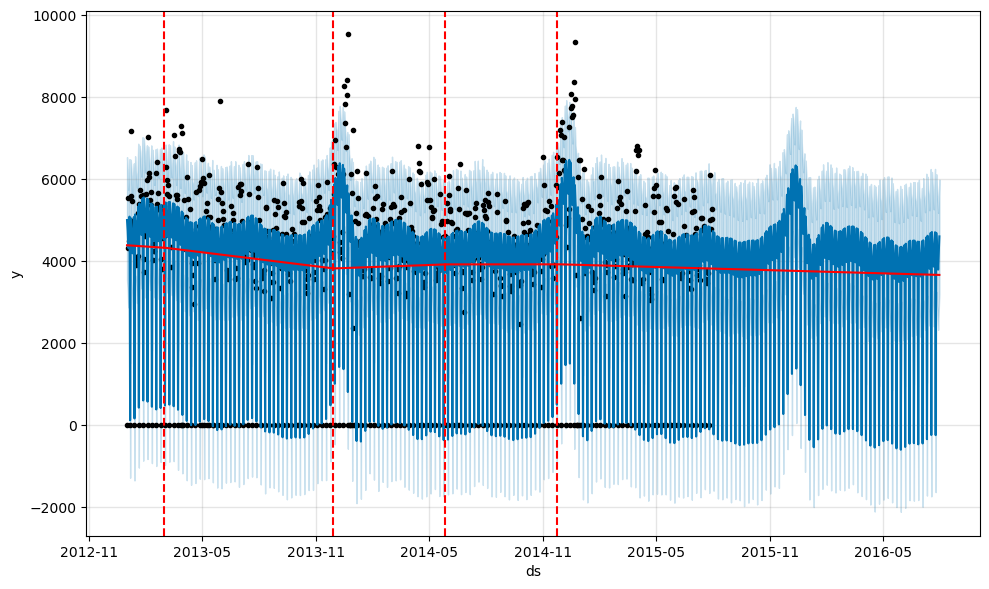

In [179]:
m_a = Prophet(changepoint_prior_scale=0.5) # by default it is 0.05
forecast_a = m_a.fit(df_p).predict(future)
fig = m_a.plot(forecast_a)
a = add_changepoints_to_plot(fig.gca(), m_a, forecast_a)

In [180]:
''' more changepoints appears now since we increased the prior leading to more flexibility'''

' more changepoints appears now since we increased the prior leading to more flexibility'

20:11:29 - cmdstanpy - INFO - Chain [1] start processing
20:11:29 - cmdstanpy - INFO - Chain [1] done processing


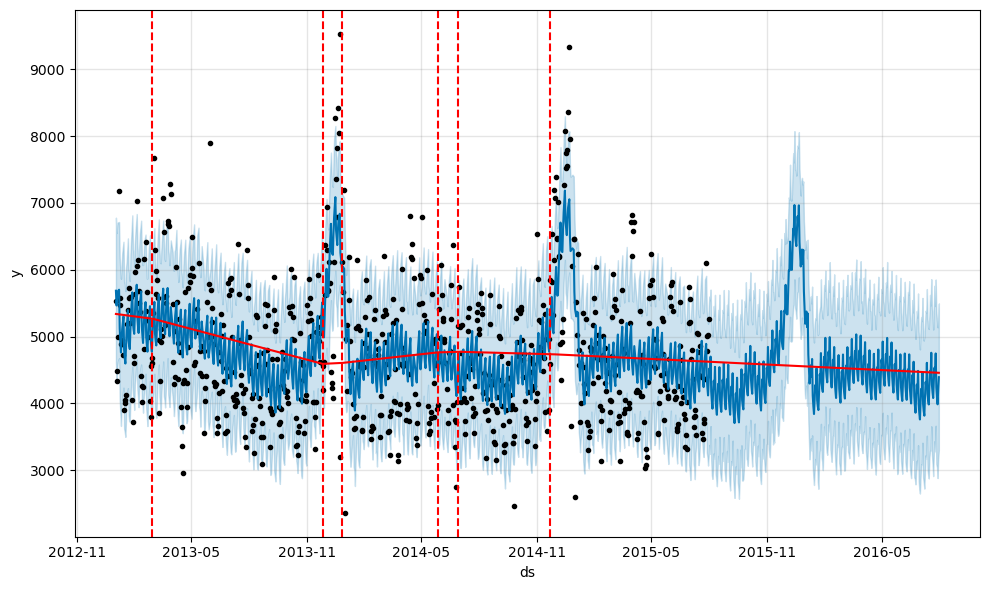

In [181]:
m2_a = Prophet(changepoint_prior_scale=0.5) # by default it is 0.05
forecast2_a = m2_a.fit(df_p2).predict(future2)
fig = m2_a.plot(forecast2_a)
a = add_changepoints_to_plot(fig.gca(), m2_a, forecast2_a)

In [183]:
''' more changepoints'''

' more changepoints'

20:11:52 - cmdstanpy - INFO - Chain [1] start processing
20:11:52 - cmdstanpy - INFO - Chain [1] done processing


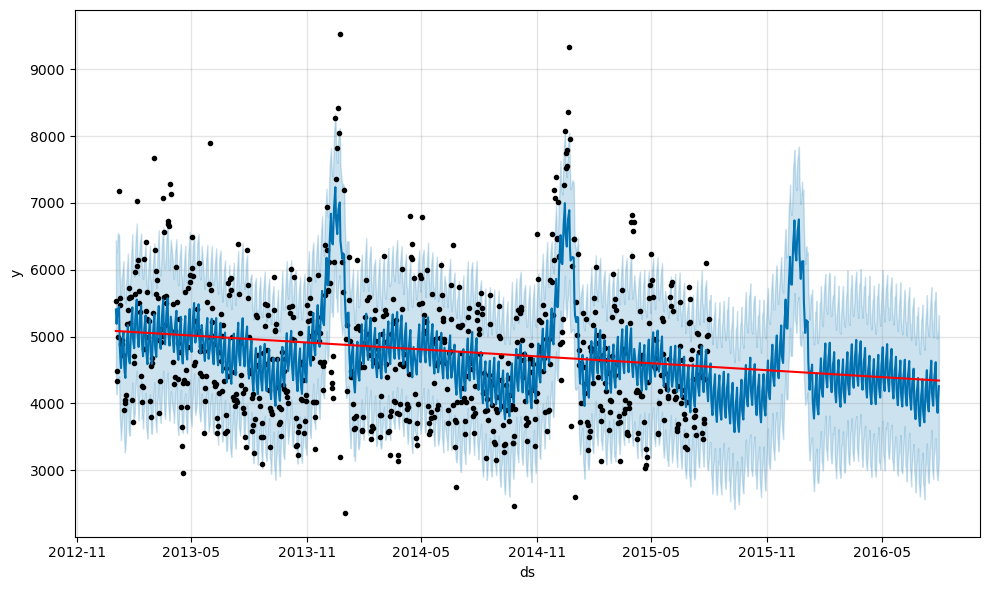

In [182]:
m2_a = Prophet(changepoint_prior_scale=0.005) # by default it is 0.05
forecast2_a = m2_a.fit(df_p2).predict(future2)
fig = m2_a.plot(forecast2_a)
a = add_changepoints_to_plot(fig.gca(), m2_a, forecast2_a)

In [184]:
''' less changepoints since we decreased the prior'''

' less changepoints since we decreased the prior'